In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score

In [184]:
# Читаем файл (замените 'your_file.csv' на ваш путь)
df = pd.read_csv('../data/Inconel_18_demo.csv', sep=',')
#df.columns = ['time', 'vf_gp', 'vf_gpp', 'vf_gp_total', 'vf_gpp_total', 'gs_gp', 'gs_gpp']
print(df.head(5))

   'Time(min)'  Gamma` isothermal  Gamma" isothermal  Gamma` total  \
0     0.000000                0.0                0.0           0.0   
1     0.001667                0.0                0.0           0.0   
2     0.003333                0.0                0.0           0.0   
3     0.005000                0.0                0.0           0.0   
4     0.006667                0.0                0.0           0.0   

   Gamma" total  Gamma` isothermal Grain Size  Gamma" isothermal Grain Size  
0           0.0                           0.0                           0.0  
1           0.0                           0.0                           0.0  
2           0.0                           0.0                           0.0  
3           0.0                           0.0                           0.0  
4           0.0                           0.0                           0.0  


In [185]:
df = df.drop(columns=['Gamma` total', 'Gamma" total'])
df.columns = ['time', 'vf_gp', 'vf_gpp', 'gs_gp', 'gs_gpp']
print(df.head(1045))

          time     vf_gp    vf_gpp     gs_gp    gs_gpp
0     0.000000  0.000000  0.000000  0.000000  0.000000
1     0.001667  0.000000  0.000000  0.000000  0.000000
2     0.003333  0.000000  0.000000  0.000000  0.000000
3     0.005000  0.000000  0.000000  0.000000  0.000000
4     0.006667  0.000000  0.000000  0.000000  0.000000
...        ...       ...       ...       ...       ...
1040  2.178000  0.000000  0.000003  0.000000  0.494277
1041  2.223000  0.000001  0.000003  0.383973  0.538429
1042  2.273000  0.000002  0.000004  0.418273  0.586523
1043  2.327000  0.000002  0.000005  0.455637  0.638911
1044  2.386000  0.000003  0.000007  0.496337  0.695975

[1045 rows x 5 columns]


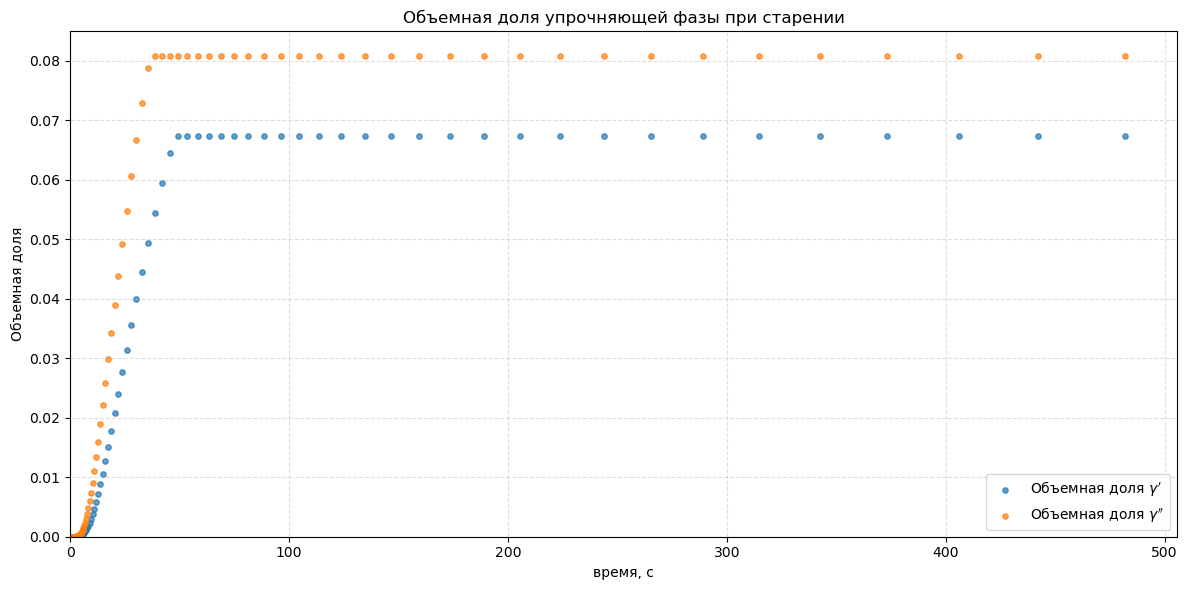

In [186]:
plt.figure(figsize=(12, 6))

# s=15 — размер точек (по умолчанию ~20-30, можно ставить 5-50)
plt.scatter(df['time'], df['vf_gp'], label=r"Объемная доля $\gamma'$",  s=15, alpha=0.7)
plt.scatter(df['time'], df['vf_gpp'], label=r"Объемная доля $\gamma''$", s=15, alpha=0.7)

# Начало осей с 0
plt.xlim(left=0)   # ось X от 0
plt.ylim(bottom=0) # ось Y от 0


plt.xlabel('время, с')
plt.ylabel('Объемная доля')
plt.title('Объемная доля упрочняющей фазы при старении')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

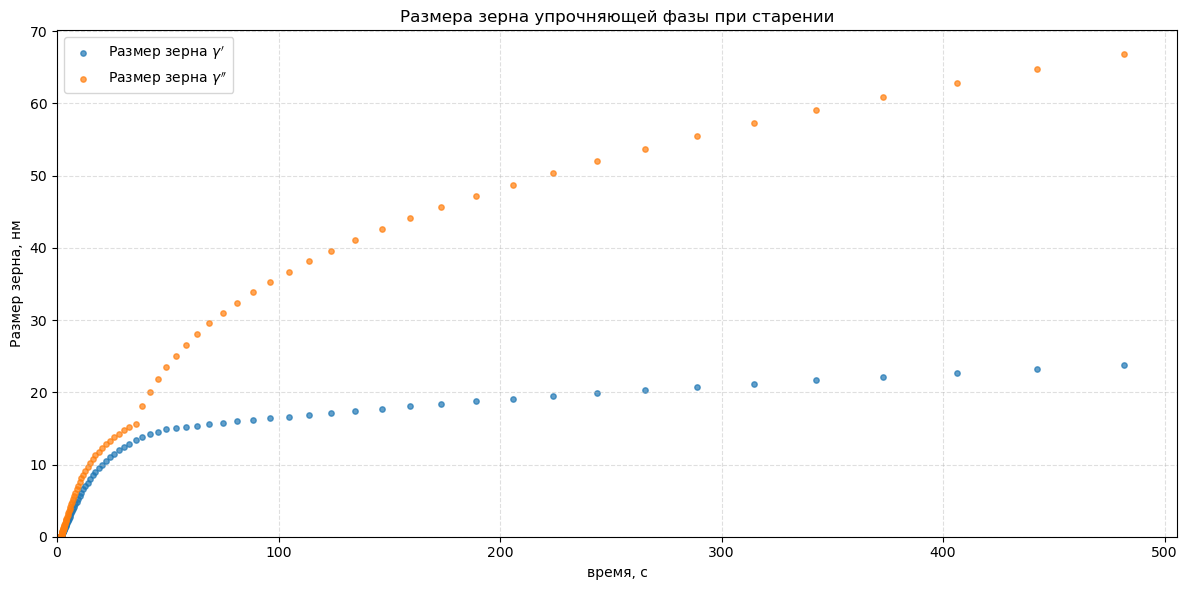

In [187]:
plt.figure(figsize=(12, 6))

# s=15 — размер точек (по умолчанию ~20-30, можно ставить 5-50)
plt.scatter(df['time'], df['gs_gp'], label=r"Размер зерна $\gamma'$",  s=15, alpha=0.7)
plt.scatter(df['time'], df['gs_gpp'], label=r"Размер зерна $\gamma''$", s=15, alpha=0.7)

# Начало осей с 0
plt.xlim(left=0)   # ось X от 0
plt.ylim(bottom=0) # ось Y от 0


plt.xlabel('время, с')
plt.ylabel('Размер зерна, нм')
plt.title('Размера зерна упрочняющей фазы при старении')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [188]:
# Создаем отдельные переменные в виде np array для времени и для функций
t = df['time'].values
X_raw = df[['vf_gp', 'vf_gpp', 'gs_gp', 'gs_gpp']].values
# Масштабируем все данные от 0 до 1
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_safe)
# Защита от нулей (добавляем малое значение вместо 0)
X_safe = np.clip(X_scaled, 1e-20, None)

In [189]:
# Вычисление производных с маскированием

def compute_derivatives_with_masking(data, t, threshold=1e-20):
    """
    Вычисляет производные с маскированием инкубационных периодов.
    
    threshold: минимальное значение переменной, при котором считаем, 
               что фаза "активна" и её производная физически осмысленна
    """
       
    n_vars = data.shape[1]
    x_dot = np.zeros_like(data)
    masks = np.ones_like(data, dtype=bool)  # по умолчанию все точки активны
    
    for i in range(n_vars):
        # Сглаживание
        smooth = savgol_filter(data[:, i], window_length=51, polyorder=3)
        # Производная
        x_dot[:, i] = np.gradient(smooth, t)
        
        # Маска: точка активна, если переменная > threshold ИЛИ уже была активна ранее
        # (чтобы не отбрасывать точки сразу после нуклеации)
        active = data[:, i] > threshold
        # Распространяем маску вперёд: если фаза "проснулась", она остаётся активной
        for j in range(1, len(active)):
            if active[j-1]:
                active[j] = True
        masks[:, i] = active
    
    return x_dot, masks

x_dot, masks = compute_derivatives_masked(X_scaled, t, threshold=1e-19)

In [190]:
masks[1040]

array([False,  True, False,  True])

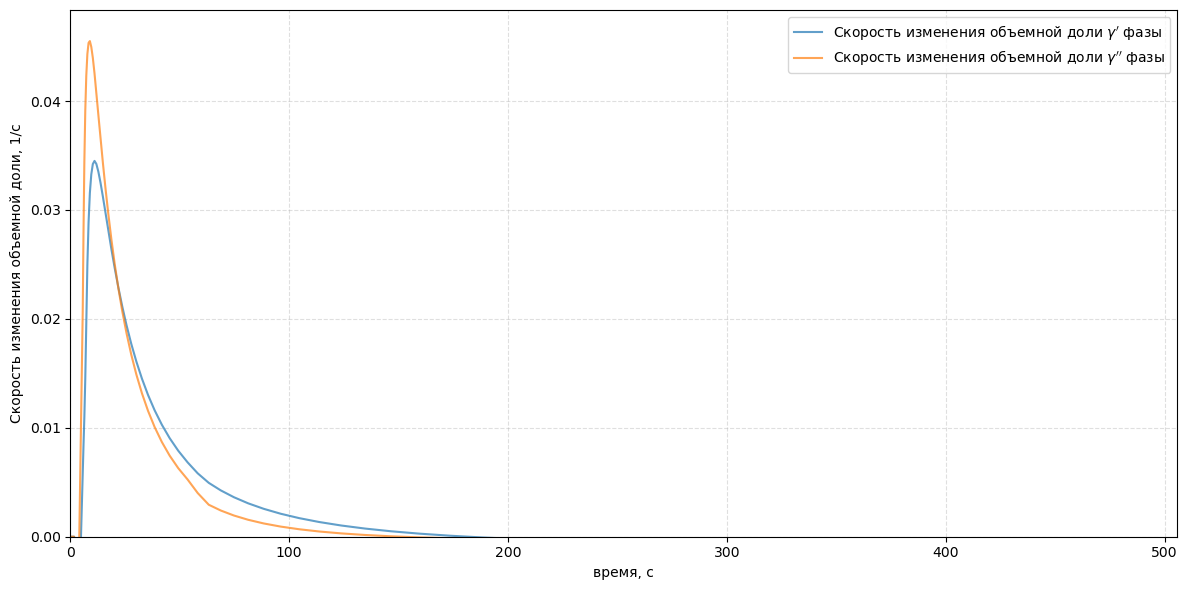

In [191]:
plt.figure(figsize=(12, 6))

plt.plot(t, x_dot[:,0], label=r"Скорость изменения объемной доли $\gamma'$ фазы",  alpha=0.7)
plt.plot(t, x_dot[:,1], label=r"Скорость изменения объемной доли $\gamma''$ фазы", alpha=0.7)

# Начало осей с 0
plt.xlim(left=0)   # ось X от 0
plt.ylim(bottom=0) # ось Y от 0


plt.xlabel('время, с')
plt.ylabel('Скорость изменения объемной доли, 1/с')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

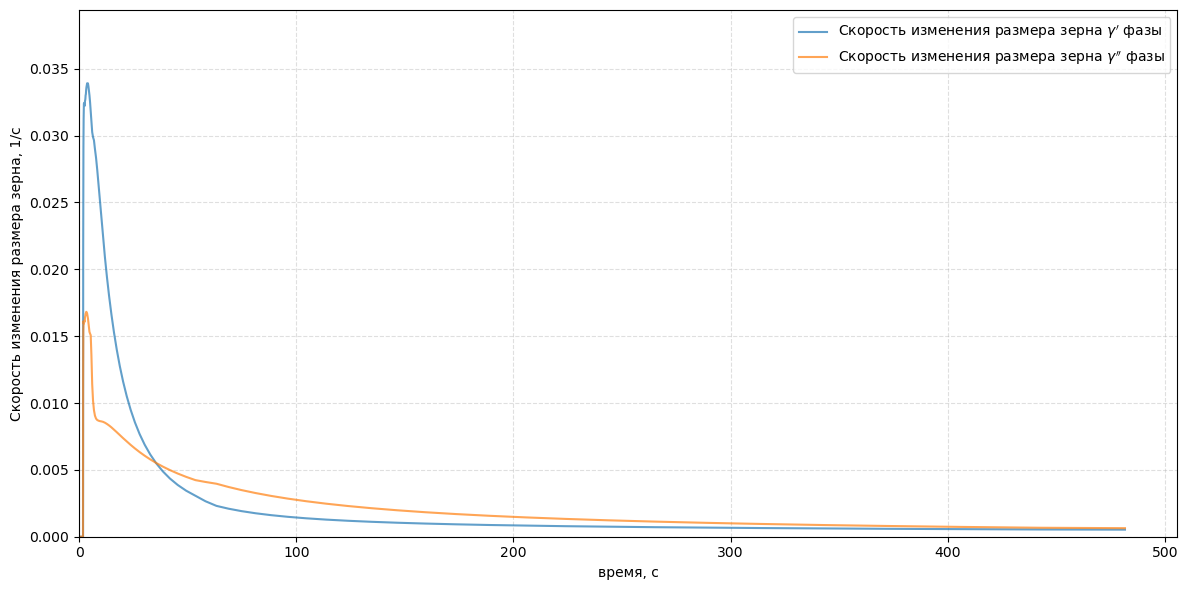

In [195]:
plt.figure(figsize=(12, 6))

plt.plot(t, x_dot[:,2], label=r"Скорость изменения размера зерна $\gamma'$ фазы",  alpha=0.7)
plt.plot(t, x_dot[:,3], label=r"Скорость изменения размера зерна $\gamma''$ фазы", alpha=0.7)

# Начало осей с 0
plt.xlim(left=0)   # ось X от 0
plt.ylim(bottom=0) # ось Y от 0


plt.xlabel('время, с')
plt.ylabel('Скорость изменения размера зерна, 1/с')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [193]:
# 4. Нормировка
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_safe)

In [194]:
X_scaled

array([[-0.19223993, -0.20011354, -0.21690373, -0.1916028 ],
       [-0.19223993, -0.20011354, -0.21690373, -0.1916028 ],
       [-0.19223993, -0.20011354, -0.21690373, -0.1916028 ],
       ...,
       [ 5.76238067,  5.48855337,  6.84229221,  8.36146146],
       [ 5.76238067,  5.48855337,  7.00864404,  8.62673933],
       [ 5.76238067,  5.48855337,  7.18156526,  8.8986454 ]],
      shape=(1121, 4))